In [1]:
import json
import os
import shutil
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as patches

dataset_path = '../FigureQA_Dataset/sample_train1'
annotations_file = os.path.join(dataset_path, 'annotations.json')
qa_file = os.path.join(dataset_path, 'qa_pairs.json')
images_dir = os.path.join(dataset_path, 'png')

## Preproccesing

Graph Type Counts:
type
vbar_categorical    200
hbar_categorical    200
line                200
pie                 200
dot_line            200
Name: count, dtype: int64


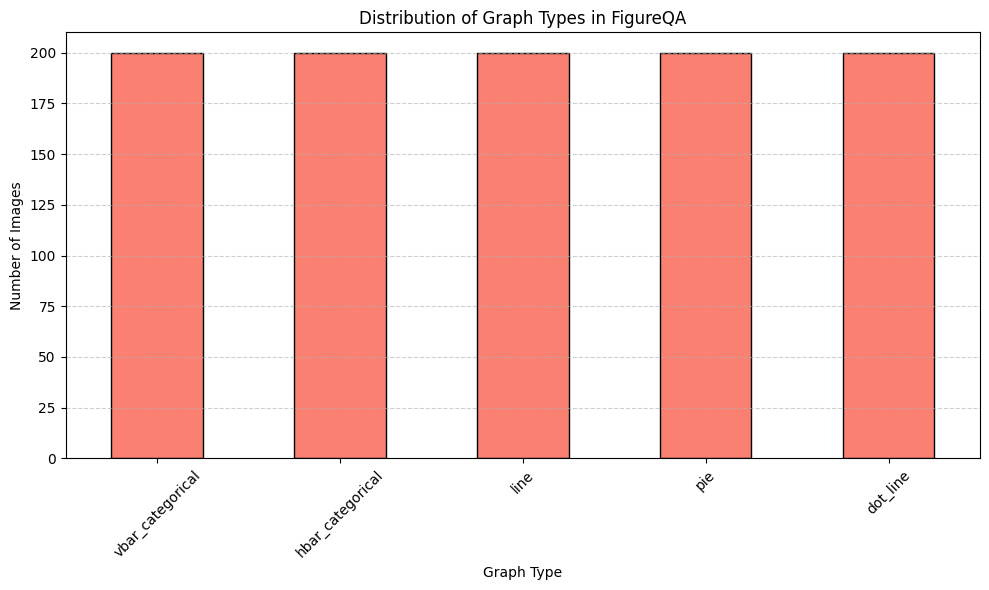

In [2]:
import pandas as pd

def get_graph_counts(file_path):
    # 1. Load the annotations
    with open(file_path, 'r') as f:
        data = json.load(f)
    
    # 2. Extract types (vbar_categorical, line, pie, etc.)
    graph_types = [item['type'] for item in data]
    
    # 3. Create a summary table
    df = pd.DataFrame(graph_types, columns=['type'])
    counts = df['type'].value_counts()
    
    print("Graph Type Counts:")
    print(counts)
    
    # 4. Visualize the distribution
    plt.figure(figsize=(10, 6))
    counts.plot(kind='bar', color='salmon', edgecolor='black')
    plt.title("Distribution of Graph Types in FigureQA")
    plt.ylabel("Number of Images")
    plt.xlabel("Graph Type")
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    # Save the plot for your records
    plt.savefig('dataset_distribution.png')
    plt.show()

# Run the analysis
get_graph_counts(annotations_file)

## Classify graph

In [3]:
output_dir = './classifier_sample_data'

def prepare_folders():
    with open(annotations_file, 'r') as f:
        annotations = json.load(f)

    for item in annotations:
        img_idx = item['image_index']
        graph_type = item['type']
        
        # Create folder for each type if it doesn't exist
        type_dir = os.path.join(output_dir, graph_type)
        os.makedirs(type_dir, exist_ok=True)
        
        # Copy image to its respective type folder
        src = os.path.join(images_dir, f"{img_idx}.png")
        dst = os.path.join(type_dir, f"{img_idx}.png")
        if os.path.exists(src):
            shutil.copy(src, dst)

    print(f"Data organized into {output_dir}")

prepare_folders()

Data organized into ./classifier_sample_data


In [4]:
import torch
import torch.nn as nn
from torchvision import datasets, models, transforms

# 1. Define Image Transformations
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 2. Load organized data
dataset = datasets.ImageFolder(output_dir, transform=data_transforms)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False)

# 3. Initialize Pre-trained ResNet18
model = models.resnet18(pretrained=True)

# Freeze early layers so we only train the new head
for param in model.parameters():
    param.requires_grad = False

# Replace the last fully connected layer
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 5) # 5 = your number of graph types

print("Model ready for training.")

Model ready for training.


/Users/aryangahlot/.pyenv/versions/tfenv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/aryangahlot/.pyenv/versions/tfenv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [5]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [6]:
import torch.optim as optim
import time

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

num_epochs = 5 

print(f"Training started on {device}...")

for epoch in range(num_epochs):
    start_time = time.time()
    
    model.train()
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / train_size
    epoch_acc = running_corrects.float() / train_size

    model.eval()
    val_corrects = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels.data)
    
    val_acc = val_corrects.float() / val_size
    
    duration = time.time() - start_time
    print(f'Epoch {epoch+1}/{num_epochs} | '
          f'Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | '
          f'Val Acc: {val_acc:.4f} | Time: {duration:.0f}s')

torch.save(model.state_dict(), 'graph_classifier.pth')
print("\nFixed! Model saved as 'graph_classifier.pth'")

Training started on mps...
Epoch 1/5 | Train Loss: 0.9718 Acc: 0.7375 | Val Acc: 0.9700 | Time: 4s
Epoch 2/5 | Train Loss: 0.2545 Acc: 0.9962 | Val Acc: 0.9850 | Time: 3s
Epoch 3/5 | Train Loss: 0.1383 Acc: 0.9987 | Val Acc: 0.9950 | Time: 5s
Epoch 4/5 | Train Loss: 0.0835 Acc: 0.9975 | Val Acc: 1.0000 | Time: 4s
Epoch 5/5 | Train Loss: 0.0618 Acc: 0.9987 | Val Acc: 0.9950 | Time: 4s

Fixed! Model saved as 'graph_classifier.pth'


Class Mapping: ['dot_line', 'hbar_categorical', 'line', 'pie', 'vbar_categorical']


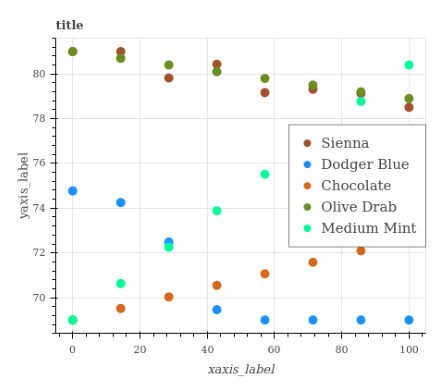


--- Vision System Output ---
Detected Graph Type: dot_line


In [7]:
import torch
from PIL import Image
import random

# 1. Setup Class Mapping
# ImageFolder assigns indices alphabetically based on folder names
class_names = dataset.classes 
print(f"Class Mapping: {class_names}")

def predict_and_summarize(image_path):
    # --- Part A: Classification ---
    model.eval()
    img = Image.open(image_path).convert('RGB')
    
    # Preprocess the image exactly like training
    img_tensor = data_transforms(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(img_tensor)
        _, preds = torch.max(outputs, 1)
        predicted_type = class_names[preds[0]]

    print(f"\n--- Vision System Output ---")
    print(f"Detected Graph Type: {predicted_type}")


# 2. Test it on a random image from your original folder
random_idx = random.randint(0, 999)
test_image_path = os.path.join(images_dir, f"{random_idx}.png")

# Show the image
plt.imshow(Image.open(test_image_path))
plt.axis('off')
plt.show()

# Run the switch
predict_and_summarize(test_image_path)

## Extracting data from vbar_categorical

Training Model on Ground Truth Values...
Epoch 1 - MSE Loss: 0.0811
Epoch 2 - MSE Loss: 0.0332
Epoch 3 - MSE Loss: 0.0263
Epoch 4 - MSE Loss: 0.0220
Epoch 5 - MSE Loss: 0.0172
Epoch 6 - MSE Loss: 0.0100
Epoch 7 - MSE Loss: 0.0094
Epoch 8 - MSE Loss: 0.0071
Epoch 9 - MSE Loss: 0.0060
Epoch 10 - MSE Loss: 0.0064
Epoch 11 - MSE Loss: 0.0045
Epoch 12 - MSE Loss: 0.0041
Epoch 13 - MSE Loss: 0.0037
Epoch 14 - MSE Loss: 0.0043
Epoch 15 - MSE Loss: 0.0049
Model saved successfully!


/Users/aryangahlot/.pyenv/versions/tfenv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


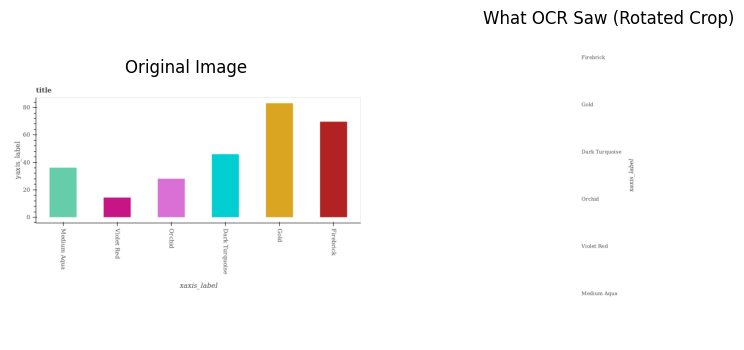

{
    "title": "title",
    "x_axis_labels": [
        "Medium Aqua",
        "Violet Red",
        "Orchid",
        "Dark Turquoise",
        "Gold",
        "Firebrick",
        "Unknown_Label_7"
    ],
    "values": [
        36.51,
        12.54,
        25.63,
        38.34,
        76.49,
        73.64,
        2.37
    ]
}


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import json
import os
import cv2
import easyocr
import numpy as np

# --- 1. CONFIGURATION ---
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
reader = easyocr.Reader(['en']) 
vbar_dir = './classifier_sample_data/vbar_categorical'
annotations_file = '../FigureQA_Dataset/sample_train1/annotations.json'

# --- 2. DATASET (Uses Real Annotations for Training) ---
class VBarValueDataset(Dataset):
    def __init__(self, image_dir, annotations_file, indices, transform=None):
        self.image_dir = image_dir
        with open(annotations_file, 'r') as f:
            full_data = json.load(f)
        # Filter for training images
        self.data = [item for item in full_data if item['image_index'] in indices]
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        img_path = os.path.join(self.image_dir, f"{item['image_index']}.png")
        image = Image.open(img_path).convert('RGB')
        
        # GROUND TRUTH: We take the REAL values from the JSON
        values = item['models'][0]['y']
        
        # Prepare target vector (fixed size of 10 for the model)
        target = torch.zeros(10) 
        val_len = min(len(values), 10)
        # Normalize 0-100 scale down to 0-1 for the model
        target[:val_len] = torch.tensor(values[:val_len]) / 100.0 
        
        if self.transform:
            image = self.transform(image)
            
        return image, target

# --- 3. MODEL (With Sigmoid to prevent negative numbers) ---
class VBarRegressor(nn.Module):
    def __init__(self):
        super(VBarRegressor, self).__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(num_ftrs, 10)
        self.sigmoid = nn.Sigmoid() # Forces output between 0 and 1

    def forward(self, x):
        x = self.backbone(x)
        return self.sigmoid(x)

# --- 4. TRAINING SETUP ---
# Re-load indices from previous step
image_files = [f for f in os.listdir(vbar_dir) if f.endswith('.png')]
indices = [int(f.split('.')[0]) for f in image_files]
train_idx = indices[:int(len(indices)*0.8)] # Simple split

# Setup Data
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
train_dataset = VBarValueDataset(vbar_dir, annotations_file, train_idx, data_transforms)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Setup Model
model = VBarRegressor().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop
print("Training Model on Ground Truth Values...")
model.train()
for epoch in range(15): # Increased epochs slightly
    running_loss = 0.0
    for images, targets in train_loader:
        images, targets = images.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    print(f"Epoch {epoch+1} - MSE Loss: {running_loss/len(train_loader):.4f}")

torch.save(model.state_dict(), "vbar_regressor.pth")
print("Model saved successfully!")

# --- 5. INFERENCE (Correct Format) ---
import cv2
import numpy as np
import json
from PIL import Image
import matplotlib.pyplot as plt

def get_graph_json_robust(image_path):
    model.eval()
    
    # --- A. Get VALUES from Model ---
    img_pil = Image.open(image_path).convert('RGB')
    input_tensor = data_transforms(img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        # Predict 0-1 and scale to 0-100
        preds = model(input_tensor).squeeze().cpu().numpy() * 100.0
    
    # --- B. Get TEXT from OCR (Improved) ---
    cv_img = cv2.imread(image_path)
    h, w, _ = cv_img.shape
    
    # 1. Title (Top 15%)
    title_res = reader.readtext(cv_img[0:int(h*0.15), :])
    title = title_res[0][1] if title_res else "Untitled"
    
    # 2. X-Axis Labels (Bottom 30% - Widened Area)
    # Start crop earlier (0.70 instead of 0.85) to catch long vertical text
    label_area = cv_img[int(h*0.70):h, :] 
    
    # Pre-processing for better OCR
    gray = cv2.cvtColor(label_area, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY_INV)
    
    # Rotate 90 degrees counter-clockwise (Standard for FigureQA)
    label_rot = cv2.rotate(label_area, cv2.ROTATE_90_COUNTERCLOCKWISE)
    
    # Read text with 'allowlist' removed to catch complex words
    label_res = reader.readtext(label_rot)
    
    # Filter noise (labels usually > 2 chars) and reverse list
    x_labels = [res[1] for res in label_res if len(res[1]) > 2]
    x_labels = x_labels[::-1]

    # --- C. Intelligent Matching ---
    # The model predicts 10 slots. We take non-zero predictions (e.g. > 1.0)
    # or match the number of labels found.
    
    valid_preds = [round(float(v), 2) for v in preds if v > 1.0] # Filter essentially zero bars
    
    # Heuristic: If we found labels, use that count. If not, use the non-zero predictions.
    count = max(len(x_labels), len(valid_preds))
    count = min(count, 10) # Cap at 10
    
    final_values = [round(float(v), 2) for v in preds[:count]]
    
    # Pad labels if OCR missed some
    while len(x_labels) < len(final_values):
        x_labels.append(f"Unknown_Label_{len(x_labels)+1}")

    return {
        "title": title,
        "x_axis_labels": x_labels,
        "values": final_values
    }, label_rot # Return image for debug

# --- VISUALIZATION BLOCK ---
# Pick an image to test
test_img_path = f"{vbar_dir}/{train_idx[0]}.png"

# Run Inference
result_json, debug_img = get_graph_json_robust(test_img_path)

# 1. Show the cropped area the OCR actually saw
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(Image.open(test_img_path))
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(debug_img)
plt.title("What OCR Saw (Rotated Crop)")
plt.axis('off')
plt.show()

# 2. Print Result
print(json.dumps(result_json, indent=4))

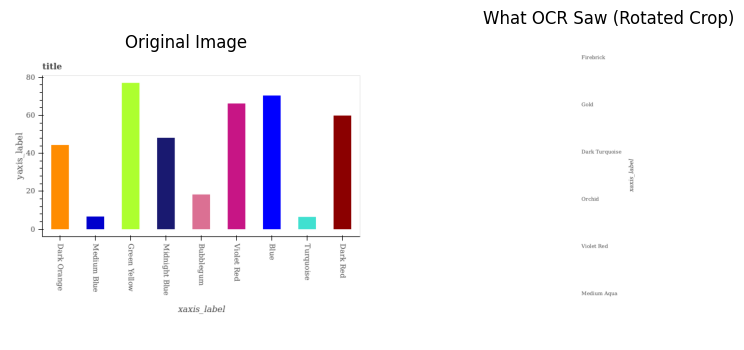

{
    "title": "title",
    "x_axis_labels": [
        "Dark Orange",
        "Medium Blue",
        "Green Yellow",
        "Midnight Blue",
        "Bubblegum",
        "Violet Red",
        "Blue",
        "Turquoise",
        "Dark Red"
    ],
    "values": [
        37.5,
        4.4,
        75.53,
        46.37,
        8.61,
        53.93,
        77.0,
        4.95,
        58.58
    ]
}


In [9]:
def get_graph_json_final(image_path):
    model.eval()
    
    # --- A. Get VALUES from Model ---
    img_pil = Image.open(image_path).convert('RGB')
    input_tensor = data_transforms(img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        # Predict 0-1 and scale to 0-100
        preds = model(input_tensor).squeeze().cpu().numpy() * 100.0
    
    # --- B. Get TEXT from OCR ---
    cv_img = cv2.imread(image_path)
    h, w, _ = cv_img.shape
    
    # 1. Title
    title_res = reader.readtext(cv_img[0:int(h*0.15), :])
    title = title_res[0][1] if title_res else "Untitled"
    
    # 2. X-Axis Labels
    label_area = cv_img[int(h*0.70):h, :] 
    label_rot = cv2.rotate(label_area, cv2.ROTATE_90_COUNTERCLOCKWISE)
    label_res = reader.readtext(label_rot)
    
    x_labels = [res[1] for res in label_res if len(res[1]) > 1]
    x_labels = x_labels[::-1]

    # --- C. Intelligent Matching (The Fix) ---
    # 1. Determine Dynamic Threshold (e.g., 5% of the max value)
    max_val = np.max(preds)
    noise_threshold = max_val * 0.05 
    
    # 2. Filter out "Ghost Bars"
    valid_preds = [v for v in preds if v > noise_threshold]
    
    # 3. Match Counts
    # If OCR and Model agree on count (after filtering), perfect.
    # If they disagree, trust the one that found MORE items (safety net),
    # but only if those items are significant.
    count = max(len(x_labels), len(valid_preds))
    count = min(count, 10) 
    
    final_values = [round(float(v), 2) for v in preds[:count]]
    
    # Pad labels ONLY if legitimate bars are missing names
    while len(x_labels) < len(final_values):
        x_labels.append(f"Unknown_Label_{len(x_labels)+1}")

    return {
        "title": title,
        "x_axis_labels": x_labels,
        "values": final_values
    }

# Run Test
test_img_path = f"{vbar_dir}/{train_idx[1]}.png"

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(Image.open(test_img_path))
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(debug_img)
plt.title("What OCR Saw (Rotated Crop)")
plt.axis('off')
plt.show()
print(json.dumps(get_graph_json_final(test_img_path), indent=4))

## Extracting data from hbar_categorical

Training Stable Masked HBar Model...
Epoch 1/40 - Masked L1 Error: 0.2408
Epoch 5/40 - Masked L1 Error: 0.1231
Epoch 10/40 - Masked L1 Error: 0.0789
Epoch 15/40 - Masked L1 Error: 0.0724
Epoch 20/40 - Masked L1 Error: 0.0626
Epoch 25/40 - Masked L1 Error: 0.0593
Epoch 30/40 - Masked L1 Error: 0.0564
Epoch 35/40 - Masked L1 Error: 0.0496
Epoch 40/40 - Masked L1 Error: 0.0483
Stable Masked HBar Model saved successfully!


--- DEBUG INFO ---
Raw Model Predictions: [53.96, 84.2, 29.12, 3.86, 76.59, 4.13, 87.42, 20.8, 91.74, 77.89]
Raw OCR Labels Found: ['Chocolate', 'Medium Periwinkle', 'Web Purple', 'Dark Slate', 'Indian Red', 'Medium Turquoise', 'Navy Blue', 'Dim Gray', 'Rosy Brown', 'Hot Pink']
------------------



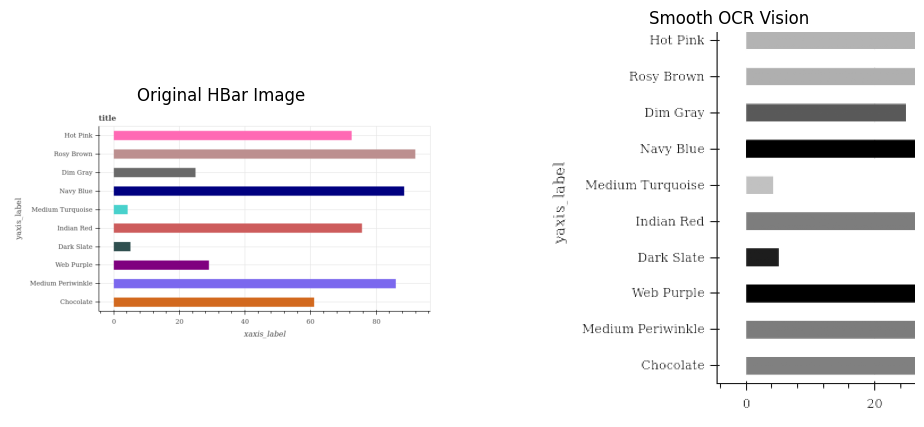

{
    "title": "title",
    "y_axis_labels": [
        "Chocolate",
        "Medium Periwinkle",
        "Web Purple",
        "Dark Slate",
        "Indian Red",
        "Medium Turquoise",
        "Navy Blue",
        "Dim Gray",
        "Rosy Brown",
        "Hot Pink"
    ],
    "values": [
        53.96,
        84.2,
        29.12,
        3.86,
        76.59,
        4.13,
        87.42,
        20.8,
        91.74,
        77.89
    ]
}


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import json
import os
import cv2
import easyocr
import numpy as np
import matplotlib.pyplot as plt

# --- 1. CONFIGURATION ---
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
reader = easyocr.Reader(['en']) 

# Ensure this path matches where your horizontal bar charts are
hbar_dir = './classifier_sample_data/hbar_categorical' 
annotations_file = '../FigureQA_Dataset/sample_train1/annotations.json'

# --- 2. DATASET (NORMALIZED & MASKED) ---
class HBarValueDataset(Dataset):
    def __init__(self, image_dir, annotations_file, indices, transform=None):
        self.image_dir = image_dir
        with open(annotations_file, 'r') as f:
            full_data = json.load(f)
        self.data = [item for item in full_data if item['image_index'] in indices]
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        img_path = os.path.join(self.image_dir, f"{item['image_index']}.png")
        image = Image.open(img_path).convert('RGB')
        
        values = item['models'][0]['x'] 
        
        target = torch.zeros(10)
        mask = torch.zeros(10)
        
        val_len = min(len(values), 10)
        # We MUST normalize to 0-1 for stable training
        target[:val_len] = torch.tensor(values[:val_len]) / 100.0 
        mask[:val_len] = 1.0 
        
        if self.transform:
            image = self.transform(image)
            
        return image, target, mask

# --- 3. STABLE MODEL ---
class HBarRegressor(nn.Module):
    def __init__(self):
        super(HBarRegressor, self).__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(num_ftrs, 10)
        # Bring Sigmoid back to stabilize learning between 0.0 and 1.0
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.backbone(x)
        return self.sigmoid(x)

# --- 4. TRAINING SETUP ---
image_files = [f for f in os.listdir(hbar_dir) if f.endswith('.png')]
indices = [int(f.split('.')[0]) for f in image_files]
train_idx = indices[:int(len(indices)*0.8)] 

data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = HBarValueDataset(hbar_dir, annotations_file, train_idx, data_transforms)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

model = HBarRegressor().to(device)

criterion = nn.L1Loss(reduction='none') 
optimizer = optim.Adam(model.parameters(), lr=0.001)

# --- 5. MASKED TRAINING LOOP ---
print("Training Stable Masked HBar Model...")
model.train()
num_epochs = 40 # Slightly longer to ensure it locks in

for epoch in range(num_epochs): 
    running_loss = 0.0
    valid_batches = 0
    
    for images, targets, masks in train_loader:
        images = images.to(device)
        targets = targets.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        
        raw_loss = criterion(outputs, targets)
        # Average only over REAL bars
        masked_loss = (raw_loss * masks).sum() / masks.sum() 
        
        masked_loss.backward()
        optimizer.step()
        
        running_loss += masked_loss.item()
        valid_batches += 1
        
    epoch_loss = running_loss / valid_batches
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{num_epochs} - Masked L1 Error: {epoch_loss:.4f}")

torch.save(model.state_dict(), "hbar_regressor_stable.pth")
print("Stable Masked HBar Model saved successfully!\n")

# --- 6. INFERENCE & SMOOTH OCR ---
def get_hbar_json_stable(image_path):
    model.eval()
    
    # 1. Get VALUES
    img_pil = Image.open(image_path).convert('RGB')
    input_tensor = data_transforms(img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        # Scale the 0-1 predictions back up to 0-100
        preds = model(input_tensor).squeeze().cpu().numpy() * 100.0
    
    # 2. Get TEXT
    cv_img = cv2.imread(image_path)
    h, w, _ = cv_img.shape
    
    title_res = reader.readtext(cv_img[0:int(h*0.15), :])
    title = title_res[0][1] if title_res else "Untitled"
    
    # OCR Crop
    label_area = cv_img[int(h*0.10):int(h*0.95), 0:int(w*0.45)] 
    gray = cv2.cvtColor(label_area, cv2.COLOR_BGR2GRAY)
    
    # SMOOTH CONTRAST: Instead of harsh binary, we gently multiply the darkness
    # This keeps the font edges smooth so EasyOCR can read "Hot Pink"
    contrast_img = cv2.convertScaleAbs(gray, alpha=1.5, beta=-50)
    
    label_res = reader.readtext(contrast_img, mag_ratio=2.0)
    y_labels = [res[1] for res in label_res if len(res[1]) > 1]
    
    y_labels = y_labels[::-1]

    print("\n--- DEBUG INFO ---")
    print(f"Raw Model Predictions: {[round(float(v), 2) for v in preds]}")
    print(f"Raw OCR Labels Found: {y_labels}")
    print("------------------\n")

    # 3. Intelligent Matching
    # Because we use Sigmoid, empty slots will be very close to 0.0 or ~50.0 depending on weight decay
    # We rely on the mask to have trained the real bars.
    valid_preds = [v for v in preds if v > 2.0]
    
    count = len(y_labels) if len(y_labels) > 0 else len(valid_preds)
    count = min(count, 10) 
    
    final_values = [round(float(v), 2) for v in preds[:count]]
    
    while len(y_labels) < len(final_values):
        y_labels.append(f"Unknown_Label_{len(y_labels)+1}")

    return {
        "title": title,
        "y_axis_labels": y_labels,
        "values": final_values
    }, contrast_img

# --- 7. TEST AND VISUALIZATION ---
test_img_path = f"{hbar_dir}/{train_idx[1]}.png"

result_json, debug_img = get_hbar_json_stable(test_img_path)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(Image.open(test_img_path))
plt.title("Original HBar Image")
plt.axis('off')

plt.subplot(1, 2, 2)
# Show the smooth contrast image
plt.imshow(debug_img, cmap='gray')
plt.title("Smooth OCR Vision")
plt.axis('off')
plt.show()

print(json.dumps(result_json, indent=4))

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


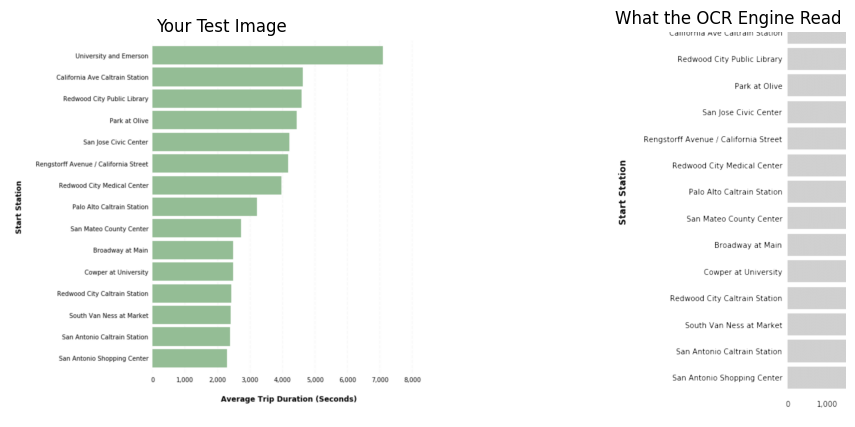


✅ EXTRACTION SUCCESSFUL:

{
    "title": "University and Emerson",
    "y_axis_labels": [
        "City",
        "City",
        "City",
        "1,000",
        "San Antonio Shopping Center",
        "San Antonio Caltrain Station",
        "South Van Ness at Marker",
        "Caltrain Station",
        "Reawood",
        "Cowper at University",
        "Broadway at Main",
        "San Mateo County Center",
        "Palo Alto Caltrain Station",
        "Medical Center",
        "Redwood",
        "Rengstorff Avenue / California Street",
        "San Jose Civic Center",
        "Park at Olive",
        "Public Library",
        "Redwood",
        "Jlaon",
        "coilam",
        "AYC",
        "cdmona"
    ],
    "values": [
        53.71,
        15.03,
        23.82,
        21.02,
        42.19,
        39.1,
        49.13,
        62.82,
        35.86,
        59.42
    ]
}


In [19]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import json
import cv2
import easyocr
import numpy as np
import matplotlib.pyplot as plt

# --- 1. SETUP & CONFIGURATION ---
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
reader = easyocr.Reader(['en']) 

# --- 2. DEFINE THE MODEL ARCHITECTURE ---
# This must match exactly how you trained it
class HBarRegressor(nn.Module):
    def __init__(self):
        super(HBarRegressor, self).__init__()
        self.backbone = models.resnet18(weights=None) # No need for pre-trained weights during inference
        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(num_ftrs, 10)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.backbone(x)
        return self.sigmoid(x)

# --- 3. LOAD THE TRAINED WEIGHTS ---
model = HBarRegressor().to(device)
# Load the weights you just saved (Make sure the filename matches what you saved)
model.load_state_dict(torch.load("hbar_regressor_stable.pth", map_location=device))
model.eval() # Set to evaluation mode

# --- 4. IMAGE TRANSFORMS ---
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# --- 5. THE EXTRACTION FUNCTION ---
def extract_hbar_data(image_path):
    # --- A. Predict Values ---
    img_pil = Image.open(image_path).convert('RGB')
    input_tensor = data_transforms(img_pil).unsqueeze(0).to(device)
    
    with torch.no_grad():
        preds = model(input_tensor).squeeze().cpu().numpy() * 100.0
    
    # --- B. Extract Text (OCR) ---
    cv_img = cv2.imread(image_path)
    h, w, _ = cv_img.shape
    
    # 1. Title
    title_res = reader.readtext(cv_img[0:int(h*0.15), :])
    title = title_res[0][1] if title_res else "Untitled"
    
    # 2. Labels (Smooth Contrast for better reading)
    label_area = cv_img[int(h*0.10):int(h*0.95), 0:int(w*0.45)] 
    gray = cv2.cvtColor(label_area, cv2.COLOR_BGR2GRAY)
    contrast_img = cv2.convertScaleAbs(gray, alpha=1.5, beta=-50)
    
    label_res = reader.readtext(contrast_img, mag_ratio=2.0)
    y_labels = [res[1] for res in label_res if len(res[1]) > 1]
    y_labels = y_labels[::-1] # Reverse because graph builds from bottom to top

    # --- C. Intelligent Matching ---
    # Filter out empty slots (model predicts ~0 for empty slots)
    valid_preds = [v for v in preds if v > 2.0]
    
    count = len(y_labels) if len(y_labels) > 0 else len(valid_preds)
    count = min(count, 10) 
    
    final_values = [round(float(v), 2) for v in preds[:count]]
    
    while len(y_labels) < len(final_values):
        y_labels.append(f"Unknown_Label_{len(y_labels)+1}")

    return {
        "title": title,
        "y_axis_labels": y_labels,
        "values": final_values
    }, contrast_img

# ==========================================
# --- 6. TEST WITH YOUR LOCAL IMAGE ---
# ==========================================

# 👇 REPLACE THIS PATH WITH YOUR ACTUAL IMAGE LOCATION 👇
my_image_path = "./Real_Test_Graph/hbar2.png" 
# Example Mac path: "/Users/aryangahlot/Desktop/my_test_graph.png"
# Example Windows path: "C:/Users/Aryan/Pictures/test_graph.png"

try:
    # Run the extraction
    result_json, debug_img = extract_hbar_data(my_image_path)

    # Plot the results side-by-side
    plt.figure(figsize=(12, 5))
    
    # Original Image
    plt.subplot(1, 2, 1)
    plt.imshow(Image.open(my_image_path))
    plt.title("Your Test Image")
    plt.axis('off')

    # OCR Vision
    plt.subplot(1, 2, 2)
    plt.imshow(debug_img, cmap='gray')
    plt.title("What the OCR Engine Read")
    plt.axis('off')
    
    plt.show()

    # Print the Final JSON Data
    print("\n✅ EXTRACTION SUCCESSFUL:\n")
    print(json.dumps(result_json, indent=4))

except FileNotFoundError:
    print(f"❌ ERROR: Could not find the image at '{my_image_path}'. Please check the path and try again.")
except Exception as e:
    print(f"❌ ERROR during extraction: {e}")

## Extracting data from pie chart

Training Stable Pie Model (Using True Percentages)...
Epoch 1/40 - Masked L1 Error: 0.1604
Epoch 5/40 - Masked L1 Error: 0.0733
Epoch 10/40 - Masked L1 Error: 0.0498
Epoch 15/40 - Masked L1 Error: 0.0400
Epoch 20/40 - Masked L1 Error: 0.0386
Epoch 25/40 - Masked L1 Error: 0.0350
Epoch 30/40 - Masked L1 Error: 0.0352
Epoch 35/40 - Masked L1 Error: 0.0292
Epoch 40/40 - Masked L1 Error: 0.0284
Stable Pie Model saved successfully!


--- 🔍 RAW OCR X-RAY ---
Found: 'title          ' | X: 0.36, Y: 0.04
Found: 'Light Seafoam  ' | X: 0.18, Y: 0.78
Found: 'Olive          ' | X: 0.12, Y: 0.83
Found: 'Coral          ' | X: 0.12, Y: 0.89
Found: 'Violet Red     ' | X: 0.16, Y: 0.95
------------------------

✅ Filtered Legend Names: ['Light Seafoam', 'Olive', 'Coral', 'Violet Red']


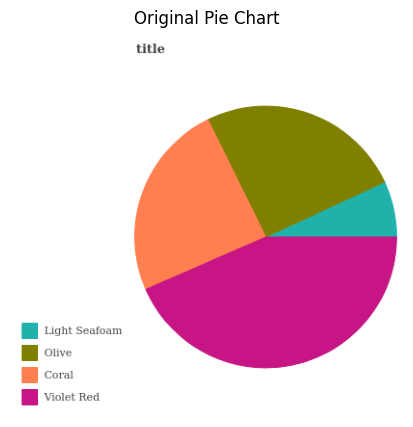


✅ FINAL JSON DICTIONARY:

{
    "title": "title",
    "data": {
        "Light Seafoam": 8.97,
        "Olive": 25.51,
        "Coral": 23.38,
        "Violet Red": 42.14
    }
}


In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import json
import os
import cv2
import easyocr
import numpy as np
import matplotlib.pyplot as plt
import math

# --- 1. CONFIGURATION ---
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
reader = easyocr.Reader(['en']) 

# Ensure this points to where your pie charts are stored
pie_dir = './classifier_sample_data/pie' 
annotations_file = '../FigureQA_Dataset/sample_train1/annotations.json'

data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# --- 2. DATASET (SPAN TO PERCENTAGE) ---
class PieChartDataset(Dataset):
    def __init__(self, image_dir, annotations_file, indices, transform=None):
        self.image_dir = image_dir
        with open(annotations_file, 'r') as f:
            full_data = json.load(f)
            
        self.data = [item for item in full_data if item['image_index'] in indices and item['type'] == 'pie']
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        img_path = os.path.join(self.image_dir, f"{item['image_index']}.png")
        image = Image.open(img_path).convert('RGB')
        
        models_data = item['models']
        values = []
        
        # Extract Percentage from Radians (span)
        for m in models_data:
            if 'span' in m:
                # 2 * pi radians = 100% of the pie
                pct = (m['span'] / (2 * math.pi)) * 100.0
                values.append(pct)
            else:
                values.append(0.0)
        
        target = torch.zeros(10)
        mask = torch.zeros(10)
        
        val_len = min(len(values), 10)
        if val_len > 0:
            target[:val_len] = torch.tensor(values[:val_len]) / 100.0 
            mask[:val_len] = 1.0 
        
        if self.transform:
            image = self.transform(image)
            
        return image, target, mask

# --- 3. 10-OUTPUT MODEL ---
class PieRegressor(nn.Module):
    def __init__(self):
        super(PieRegressor, self).__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(num_ftrs, 10)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.backbone(x)
        return self.sigmoid(x)

# --- 4. TRAINING SETUP ---
image_files = [f for f in os.listdir(pie_dir) if f.endswith('.png')]
indices = [int(f.split('.')[0]) for f in image_files]
train_idx = indices[:int(len(indices)*0.8)] 

train_dataset = PieChartDataset(pie_dir, annotations_file, train_idx, data_transforms)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

model = PieRegressor().to(device)
criterion = nn.L1Loss(reduction='none') 
optimizer = optim.Adam(model.parameters(), lr=0.001)

# --- 5. MASKED TRAINING LOOP ---
print("Training Stable Pie Model (Using True Percentages)...")
model.train()
num_epochs = 40 

for epoch in range(num_epochs): 
    running_loss = 0.0
    valid_batches = 0
    for images, targets, masks in train_loader:
        images, targets, masks = images.to(device), targets.to(device), masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        
        raw_loss = criterion(outputs, targets)
        masked_loss = (raw_loss * masks).sum() / masks.sum() 
        
        masked_loss.backward()
        optimizer.step()
        
        running_loss += masked_loss.item()
        valid_batches += 1
        
    epoch_loss = running_loss / valid_batches
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{num_epochs} - Masked L1 Error: {epoch_loss:.4f}")

torch.save(model.state_dict(), "pie_regressor_stable.pth")
print("Stable Pie Model saved successfully!\n")

# --- 6. FULL-IMAGE OCR WITH 100% SUM ENFORCEMENT ---
def extract_pie_chart_data(image_path):
    model.eval()
    
    # --- A. Predict Slice Values ---
    img_pil = Image.open(image_path).convert('RGB')
    input_tensor = data_transforms(img_pil).unsqueeze(0).to(device)
    
    with torch.no_grad():
        preds = model(input_tensor).squeeze().cpu().numpy() * 100.0
    
    # --- B. Read Entire Image ---
    cv_img = cv2.imread(image_path)
    h, w, _ = cv_img.shape
    gray = cv2.cvtColor(cv_img, cv2.COLOR_BGR2GRAY)
    
    all_text_results = reader.readtext(gray, mag_ratio=2.5)
    
    # --- C. Spatial Sorting ---
    title = "Untitled"
    raw_legend_names = [] 
    
    print("\n--- 🔍 RAW OCR X-RAY ---")
    for bbox, text, conf in all_text_results:
        clean_text = text.strip()
        if not clean_text:
            continue
            
        x_center = (bbox[0][0] + bbox[2][0]) / 2
        y_center = (bbox[0][1] + bbox[2][1]) / 2
        
        x_pct = x_center / w
        y_pct = y_center / h
        
        print(f"Found: '{clean_text:15}' | X: {x_pct:.2f}, Y: {y_pct:.2f}")
        
        # 1. TITLE (Top 15%)
        if y_pct < 0.15:
            title = clean_text
            
        # 2. LEGEND (Anywhere below the title for Pie Charts)
        elif y_pct > 0.15:
            if len(clean_text) > 2 and not clean_text.replace('.', '', 1).isdigit():
                if clean_text.lower() == "grav": clean_text = "Gray"
                raw_legend_names.append((y_pct, clean_text)) 
                
    print("------------------------\n")

    # Sort legend Top-to-Bottom by Y coordinate
    legend_names = [item[1] for item in sorted(raw_legend_names, key=lambda i: i[0])]
    print(f"✅ Filtered Legend Names: {legend_names}")

    # --- D. Format Dictionary & Force 100% Sum ---
    num_slices = len(legend_names)
    
    # Fallback if OCR missed entirely
    if num_slices == 0:
        valid_preds = [v for v in preds if v > 1.5]
        num_slices = len(valid_preds)
        
    num_slices = min(num_slices, 10)
    
    # Isolate ONLY the predictions for the slices we actually have
    slice_preds = preds[:num_slices]
    
    # Normalize those exact slices so they perfectly equal 100%
    total_pred = sum(slice_preds)
    if total_pred > 0:
        normalized_preds = [(v / total_pred) * 100.0 for v in slice_preds]
    else:
        normalized_preds = slice_preds
    
    final_slices = {}
    for i in range(num_slices):
        slice_name = legend_names[i] if i < len(legend_names) else f"Unknown_Slice_{i+1}"
        slice_value = round(normalized_preds[i], 2) if i < len(normalized_preds) else 0.0
        final_slices[slice_name] = slice_value

    return {
        "title": title,
        "data": final_slices
    }

# --- 7. EXECUTION ---
test_img_path = f"{pie_dir}/{train_idx[0]}.png"

try:
    result_json = extract_pie_chart_data(test_img_path)

    plt.figure(figsize=(8, 5))
    plt.imshow(Image.open(test_img_path))
    plt.title("Original Pie Chart")
    plt.axis('off')
    plt.show()

    print("\n✅ FINAL JSON DICTIONARY:\n")
    print(json.dumps(result_json, indent=4))
    
except Exception as e:
    print(f"Error testing pie chart: {e}")


--- 🔍 RAW OCR X-RAY ---
Found: 'Recommended Diet' | X: 0.49, Y: 0.11
Found: 'Fcuil          ' | X: 0.83, Y: 0.33
Found: 'Protcin        ' | X: 0.85, Y: 0.43
Found: 'Uvczctab c5    ' | X: 0.86, Y: 0.52
Found: 'Daln           ' | X: 0.83, Y: 0.61
Found: 'Gralts         ' | X: 0.84, Y: 0.70
Found: 'Klothe:        ' | X: 0.82, Y: 0.79
------------------------

✅ Filtered Legend Names: ['Fcuil', 'Protcin', 'Uvczctab c5', 'Daln', 'Gralts', 'Klothe:']


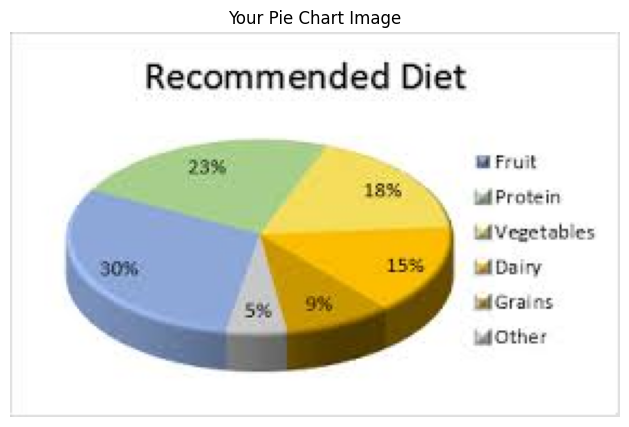


✅ FINAL JSON DICTIONARY:

{
    "title": "Recommended Diet",
    "data": {
        "Fcuil": 28.06,
        "Protcin": 18.35,
        "Uvczctab c5": 14.57,
        "Daln": 24.01,
        "Gralts": 5.38,
        "Klothe:": 9.62
    }
}


In [33]:
# ==========================================
# --- 7. TEST WITH ANY LOCAL IMAGE ---
# ==========================================

# 👇 REPLACE THIS PATH WITH YOUR ACTUAL IMAGE LOCATION 👇
my_image_path = "./Real_Test_Graph/imagespie.jpeg" 

try:
    # Run the extraction function
    result_json = extract_pie_chart_data(my_image_path)

    # Display the image side-by-side with the results
    plt.figure(figsize=(8, 5))
    plt.imshow(Image.open(my_image_path))
    plt.title("Your Pie Chart Image")
    plt.axis('off')
    plt.show()

    # Print the clean JSON data
    print("\n✅ FINAL JSON DICTIONARY:\n")
    print(json.dumps(result_json, indent=4))
    
except FileNotFoundError:
    print(f"❌ ERROR: Could not find the image at '{my_image_path}'. Please check the path and try again.")
except Exception as e:
    print(f"❌ ERROR testing pie chart: {e}")

## Training on real dataset for classifiers

In [4]:
import os
import json
import shutil

# Base directory as seen in your screenshot
base_dir = '../FigureQA_Dataset'

# Explicit Train and Validation directories
train_dir = os.path.join(base_dir, 'train1')
val_dir = os.path.join(base_dir, 'validation1')

train_annots = os.path.join(train_dir, 'annotations.json')
val_annots = os.path.join(val_dir, 'annotations.json')

train_images_dir = os.path.join(train_dir, 'png')
val_images_dir = os.path.join(val_dir, 'png')
print("Starting")

Starting


In [11]:
output_dir = './classifier_data'

def prepare_folders(source_images_dir, annotations_file, target_base_dir):
    with open(annotations_file, 'r') as f:
        annotations = json.load(f)

    for item in annotations:
        img_idx = item['image_index']
        graph_type = item['type']
        
        # Create folder for each type inside train/val
        type_dir = os.path.join(target_base_dir, graph_type)
        os.makedirs(type_dir, exist_ok=True)
        
        # Copy image
        src = os.path.join(source_images_dir, f"{img_idx}.png")
        dst = os.path.join(type_dir, f"{img_idx}.png")
        if os.path.exists(src):
            shutil.copy(src, dst)

    print(f"Data organized into {target_base_dir}")

# Run for both Train and Validation sets
prepare_folders(train_images_dir, train_annots, os.path.join(output_dir, 'train'))
prepare_folders(val_images_dir, val_annots, os.path.join(output_dir, 'val'))

Data organized into ./classifier_data/train
Data organized into ./classifier_data/val


In [12]:
from torchvision import datasets, models, transforms
import torch
import torch.nn as nn

data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load directly from the specific train and val folders
train_dataset = datasets.ImageFolder(os.path.join(output_dir, 'train'), transform=data_transforms)
val_dataset = datasets.ImageFolder(os.path.join(output_dir, 'val'), transform=data_transforms)

train_size = len(train_dataset)
val_size = len(val_dataset)
print(f"Training images: {train_size}, Validation images: {val_size}")

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False)

# Initialize Pre-trained ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(train_dataset.classes))

print("Classification model ready for training.")

Training images: 100000, Validation images: 20000
Classification model ready for training.


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import os
from torchvision import datasets, models, transforms

# 1. Setup hardware acceleration
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

# ==========================================
# 2. EXPLICITLY LOAD CLASSIFIER DATA
# ==========================================
output_dir = './classifier_data'
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load data specifically from the train/val folders
train_dataset = datasets.ImageFolder(os.path.join(output_dir, 'train'), transform=data_transforms)
val_dataset = datasets.ImageFolder(os.path.join(output_dir, 'val'), transform=data_transforms)

train_size = len(train_dataset)
val_size = len(val_dataset)

# Note: Renamed to 'class_train_loader' to avoid conflicts with the regression step!
class_train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
class_val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False)

# ==========================================
# 3. SETUP MODEL & LOSS
# ==========================================
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(train_dataset.classes))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# ==========================================
# 4. TRAINING LOOP
# ==========================================
num_epochs = 5 
print(f"Training Classification Model on {device} with {train_size} images...")


for epoch in range(num_epochs):
    start_time = time.time()
    
    # --- TRAINING PHASE ---
    model.train()
    running_loss = 0.0
    running_corrects = 0

    # Ensure we use the freshly loaded classification data
    for i, (inputs, labels) in enumerate(class_train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        
        if (i + 1) % 500 == 0:
            print(f"   Epoch {epoch+1} | Processed {i+1}/{len(class_train_loader)} batches... Loss: {loss.item():.4f}")

    epoch_loss = running_loss / train_size
    epoch_acc = running_corrects.float() / train_size

    # --- VALIDATION PHASE ---
    model.eval()
    val_corrects = 0
    with torch.no_grad():
        for inputs, labels in class_val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels.data)
    
    val_acc = val_corrects.float() / val_size
    
    duration = time.time() - start_time
    print(f'*** Epoch {epoch+1}/{num_epochs} COMPLETE | '
          f'Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | '
          f'Val Acc: {val_acc:.4f} | Time: {duration:.0f}s ***\n')

# Save the model weights 
torch.save(model.state_dict(), 'graph_classifier_real.pth')
print("\nSuccess! Model saved as 'graph_classifier_real.pth'")

Training Classification Model on mps with 100000 images...
   Epoch 1 | Processed 500/3125 batches... Loss: 0.0221
   Epoch 1 | Processed 1000/3125 batches... Loss: 0.0048
   Epoch 1 | Processed 1500/3125 batches... Loss: 0.0009
   Epoch 1 | Processed 2000/3125 batches... Loss: 0.0010
   Epoch 1 | Processed 2500/3125 batches... Loss: 0.0007
   Epoch 1 | Processed 3000/3125 batches... Loss: 0.0003
*** Epoch 1/5 COMPLETE | Train Loss: 0.0193 Acc: 0.9971 | Val Acc: 1.0000 | Time: 470s ***

   Epoch 2 | Processed 500/3125 batches... Loss: 0.0172
   Epoch 2 | Processed 1000/3125 batches... Loss: 0.0003
   Epoch 2 | Processed 1500/3125 batches... Loss: 0.0001
   Epoch 2 | Processed 2000/3125 batches... Loss: 0.0000
   Epoch 2 | Processed 2500/3125 batches... Loss: 0.0000
   Epoch 2 | Processed 3000/3125 batches... Loss: 0.0020
*** Epoch 2/5 COMPLETE | Train Loss: 0.0016 Acc: 0.9996 | Val Acc: 1.0000 | Time: 472s ***

   Epoch 3 | Processed 500/3125 batches... Loss: 0.0001
   Epoch 3 | Proces

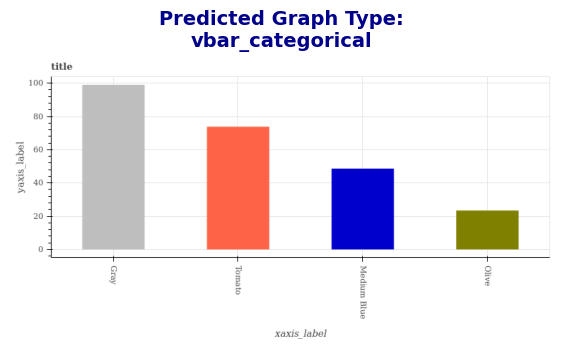

--- Classification Result ---
File: 17494.png
Detected Type: vbar_categorical



'vbar_categorical'

In [1]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import os
import random

# 1. Setup hardware acceleration
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

# 2. Define the exact class names your model learned
# (PyTorch ImageFolder sorts folders alphabetically)
class_names = ['dot_line', 'hbar_categorical', 'line', 'pie', 'vbar_categorical']

# 3. Re-initialize the model architecture
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(class_names))

# Load your newly trained weights!
model.load_state_dict(torch.load('graph_classifier_real.pth', map_location=device))
model = model.to(device)
model.eval() # Important: Set to evaluation mode (turns off training mechanics)

# 4. Define the exact same image transformations used in training
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 5. Create the universal prediction function
def classify_graph(image_path):
    # Open image and convert to RGB (just in case it has an alpha channel)
    img = Image.open(image_path).convert('RGB')
    
    # Apply transforms and add a batch dimension so it matches training shape
    img_tensor = data_transforms(img).unsqueeze(0).to(device)
    
    # Run the model
    with torch.no_grad():
        outputs = model(img_tensor)
        _, preds = torch.max(outputs, 1)
        predicted_class = class_names[preds[0].item()]
    
    # Display the result visually
    plt.figure(figsize=(7, 5))
    plt.imshow(img)
    plt.title(f"Predicted Graph Type:\n{predicted_class}", fontsize=14, fontweight='bold', color='darkblue')
    plt.axis('off')
    plt.show()
    
    print(f"--- Classification Result ---")
    print(f"File: {os.path.basename(image_path)}")
    print(f"Detected Type: {predicted_class}\n")
    
    return predicted_class

# ==========================================
# 6. TEST IT ON AN UNSEEN REAL DATASET IMAGE
# ==========================================
test_dir = '../FigureQA_Dataset/no_annot_test1/png'

# Pick a random image from the real test set
all_test_images = [f for f in os.listdir(test_dir) if f.endswith('.png')]
random_test_image = os.path.join(test_dir, random.choice(all_test_images))

# Run your new tool!
detected_type = classify_graph(random_test_image)
detected_type

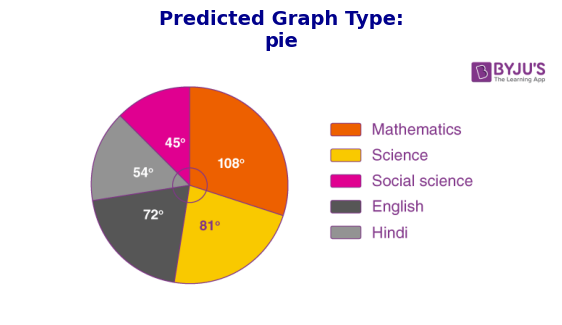

--- Classification Result ---
File: PieChart.png
Detected Type: pie



'pie'

In [2]:
classify_graph("./Real_Test_Graph/PieChart.png")

## Graph Data Extraction real data

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import json
import os
import math
from tqdm import tqdm

# --- 1. CONFIGURATION & AUGMENTATION ---
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")

train_dir = './classifier_data/train/pie'
val_dir = './classifier_data/val/pie'
train_annotations_file = '../FigureQA_Dataset/train1/annotations.json' 
val_annotations_file = '../FigureQA_Dataset/validation1/annotations.json'

# Heavy Augmentation for Training (Fixes Domain Shift)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomRotation(degrees=45),
    transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Clean transforms for Validation
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# --- 2. DATASET ---
class PieChartDataset(Dataset):
    def __init__(self, image_dir, annotations_file, transform=None):
        self.image_dir = image_dir
        
        print(f"Loading JSON annotations from {annotations_file}...")
        with open(annotations_file, 'r') as f:
            full_data = json.load(f)
            
        valid_indices = {int(f.split('.')[0]) for f in os.listdir(image_dir) if f.endswith('.png')}
        self.data = [item for item in full_data if item['image_index'] in valid_indices and item['type'] == 'pie']
        self.transform = transform
        print(f"Dataset ready! Found {len(self.data)} valid pie charts.\n")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        img_path = os.path.join(self.image_dir, f"{item['image_index']}.png")
        image = Image.open(img_path).convert('RGB')
        
        models_data = item['models']
        values = []
        
        for m in models_data:
            if 'span' in m:
                pct = (m['span'] / (2 * math.pi)) * 100.0
                values.append(pct)
            else:
                values.append(0.0)
                
        # ⚡ CRITICAL FIX: Sort the values from Largest to Smallest
        values.sort(reverse=True)
        
        target = torch.zeros(10)
        mask = torch.zeros(10)
        
        val_len = min(len(values), 10)
        if val_len > 0:
            target[:val_len] = torch.tensor(values[:val_len]) / 100.0 
            mask[:val_len] = 1.0 
        
        if self.transform:
            image = self.transform(image)
            
        return image, target, mask

# --- 3. 10-OUTPUT MODEL ---
class PieRegressor(nn.Module):
    def __init__(self):
        super(PieRegressor, self).__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(num_ftrs, 10)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.backbone(x)
        return self.sigmoid(x)

# --- 4. DATA LOADERS (Jupyter Safe) ---
print("Loading datasets...")
train_dataset = PieChartDataset(train_dir, train_annotations_file, train_transforms)
val_dataset = PieChartDataset(val_dir, val_annotations_file, val_transforms)

# ⚡ CRITICAL FIX: num_workers=0 and pin_memory=False to stop Jupyter from crashing on Mac!
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=False)

model = PieRegressor().to(device)
criterion = nn.L1Loss(reduction='none') 
optimizer = optim.Adam(model.parameters(), lr=0.001)

# --- 5. TRAINING LOOP ---
num_epochs = 10  # 10 Epochs is a good starting point to let the model learn through the augmentation

for epoch in range(num_epochs): 
    print(f"\n========== Epoch {epoch+1}/{num_epochs} ==========")
    model.train()
    train_loss = 0.0
    train_batches = 0
    
    train_loop = tqdm(train_loader, desc="Training", leave=True)
    for images, targets, masks in train_loop:
        images, targets, masks = images.to(device), targets.to(device), masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        raw_loss = criterion(outputs, targets)
        masked_loss = (raw_loss * masks).sum() / masks.sum() 
        masked_loss.backward()
        optimizer.step()
        
        train_loss += masked_loss.item()
        train_batches += 1
        train_loop.set_postfix(loss=masked_loss.item())
        
    epoch_train_loss = train_loss / train_batches if train_batches > 0 else 0
    
    # Validation Phase
    model.eval()
    val_loss = 0.0
    val_batches = 0
    val_loop = tqdm(val_loader, desc="Validating", leave=True)
    
    with torch.no_grad():
        for images, targets, masks in val_loop:
            images, targets, masks = images.to(device), targets.to(device), masks.to(device)
            outputs = model(images)
            raw_loss = criterion(outputs, targets)
            
            mask_sum = masks.sum()
            if mask_sum > 0:
                masked_loss = (raw_loss * masks).sum() / mask_sum
                val_loss += masked_loss.item()
                val_batches += 1
                val_loop.set_postfix(loss=masked_loss.item())
                
    epoch_val_loss = val_loss / val_batches if val_batches > 0 else 0
    print(f"-> Epoch {epoch+1} Summary | Train Masked L1: {epoch_train_loss:.4f} | Val Masked L1: {epoch_val_loss:.4f}")

torch.save(model.state_dict(), "pie_regressor_real.pth")
print("\n✅ Robust Pie Model saved successfully!")

Loading datasets...
Loading JSON annotations from ../FigureQA_Dataset/train1/annotations.json...
Dataset ready! Found 20000 valid pie charts.

Loading JSON annotations from ../FigureQA_Dataset/validation1/annotations.json...
Dataset ready! Found 4000 valid pie charts.


========== Epoch 1/10 ==========


Validating: 100%|███████████████████████████████████████████████████████████████████████████████████████████| 125/125 [00:13<00:00,  9.25it/s, loss=0.0213]


-> Epoch 1 Summary | Train Masked L1: 0.0354 | Val Masked L1: 0.0226

========== Epoch 2/10 ==========


Validating: 100%|███████████████████████████████████████████████████████████████████████████████████████████| 125/125 [00:14<00:00,  8.82it/s, loss=0.0154]


-> Epoch 2 Summary | Train Masked L1: 0.0205 | Val Masked L1: 0.0166

========== Epoch 3/10 ==========


...

-> Epoch 8 Summary | Train Masked L1: 0.0109 | Val Masked L1: 0.0105

========== Epoch 9/10 ==========


Validating: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 125/125 [00:16<00:00,  7.81it/s, loss=0.00816]


-> Epoch 9 Summary | Train Masked L1: 0.0098 | Val Masked L1: 0.0087

========== Epoch 10/10 ==========


Validating: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 125/125 [00:16<00:00,  7.75it/s, loss=0.00841]

-> Epoch 10 Summary | Train Masked L1: 0.0097 | Val Masked L1: 0.0101

✅ Robust Pie Model saved successfully!


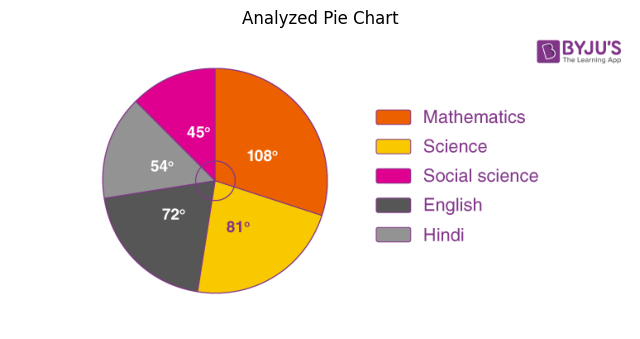


✅ FINAL JSON DICTIONARY:

{
    "title": "Tha Learning App",
    "data": {
        "Mathematics": 27.98,
        "Science": 25.23,
        "Social science": 20.35,
        "English": 14.93,
        "Hindi": 11.51
    }
}


In [3]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import cv2
import easyocr
import numpy as np
import matplotlib.pyplot as plt
import json

# --- 1. CONFIGURATION ---
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
reader = easyocr.Reader(['en'], gpu=(torch.cuda.is_available() or torch.backends.mps.is_available())) 

# Inference uses clean transforms
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# --- 2. LOAD MODEL ---
class PieRegressor(nn.Module):
    def __init__(self):
        super(PieRegressor, self).__init__()
        self.backbone = models.resnet18(weights=None)
        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(num_ftrs, 10)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.backbone(x)
        return self.sigmoid(x)

model = PieRegressor().to(device)
model.load_state_dict(torch.load("pie_regressor_real.pth", map_location=device))
model.eval()

# --- 3. INFERENCE PIPELINE ---
def extract_pie_chart_data(image_path):
    img_pil = Image.open(image_path).convert('RGB')
    input_tensor = data_transforms(img_pil).unsqueeze(0).to(device)
    
    with torch.no_grad():
        preds = model(input_tensor).squeeze().cpu().numpy() * 100.0
    
    cv_img = cv2.imread(image_path)
    h, w, _ = cv_img.shape
    gray = cv2.cvtColor(cv_img, cv2.COLOR_BGR2GRAY)
    all_text_results = reader.readtext(gray, mag_ratio=2.5)
    
    title = "Untitled"
    raw_legend_names = [] 
    
    for bbox, text, conf in all_text_results:
        clean_text = text.strip()
        if not clean_text: continue
            
        x_center = (bbox[0][0] + bbox[2][0]) / 2
        y_center = (bbox[0][1] + bbox[2][1]) / 2
        y_pct = y_center / h
        
        if y_pct < 0.15:
            title = clean_text
        elif y_pct >= 0.15:
            if len(clean_text) > 2 and not clean_text.replace('.', '', 1).isdigit():
                if clean_text.lower() == "grav": clean_text = "Gray"
                raw_legend_names.append((y_pct, clean_text)) 
                
    legend_names = [item[1] for item in sorted(raw_legend_names, key=lambda i: i[0])]
    
    num_slices = len(legend_names)
    if num_slices == 0:
        valid_preds = [v for v in preds if v > 1.5]
        num_slices = len(valid_preds)
        
    num_slices = min(num_slices, 10) 
    
    # ⚡ CRITICAL FIX: Sort Predictions from Largest to Smallest to match Legend Order
    slice_preds = sorted(preds[:num_slices], reverse=True)
    
    total_pred = sum(slice_preds)
    if total_pred > 0:
        normalized_preds = [(v / total_pred) * 100.0 for v in slice_preds]
    else:
        normalized_preds = slice_preds
    
    final_slices = {}
    for i in range(num_slices):
        slice_name = legend_names[i] if i < len(legend_names) else f"Category_{i+1}"
        slice_value = round(normalized_preds[i], 2) if i < len(normalized_preds) else 0.0
        final_slices[slice_name] = slice_value

    return {
        "title": title,
        "data": final_slices
    }

# --- 4. EXECUTION ---
test_img_path = './Real_Test_Graph/PieChart.png' # Make sure this points to your real test image!

try:
    result_json = extract_pie_chart_data(test_img_path)

    plt.figure(figsize=(8, 5))
    plt.imshow(Image.open(test_img_path))
    plt.title("Analyzed Pie Chart")
    plt.axis('off')
    plt.show()

    print("\n✅ FINAL JSON DICTIONARY:\n")
    print(json.dumps(result_json, indent=4))
    
except Exception as e:
    print(f"Error testing pie chart: {e}")

🧠 Booting up STEM Sight AI Models...

🚀 Analyzing: ./../FigureQA_Dataset/no_annot_test1/png/17.png
----------------------------------------
📊 Top Prediction: VBAR_CATEGORICAL
  Confidence Scores:
    - dot_line: 0.00%
    - hbar_categorical: 0.00%
    - line: 0.00%
    - pie: 0.00%
    - vbar_categorical: 100.00%

📈 FINAL EXTRACTED DATA:
  xaxis label: 41.47
  xaxis label: 63.99
  xaxis label: 43.79
  xaxis label: 54.23
  xaxis label: 65.46
  xaxis label: 82.69


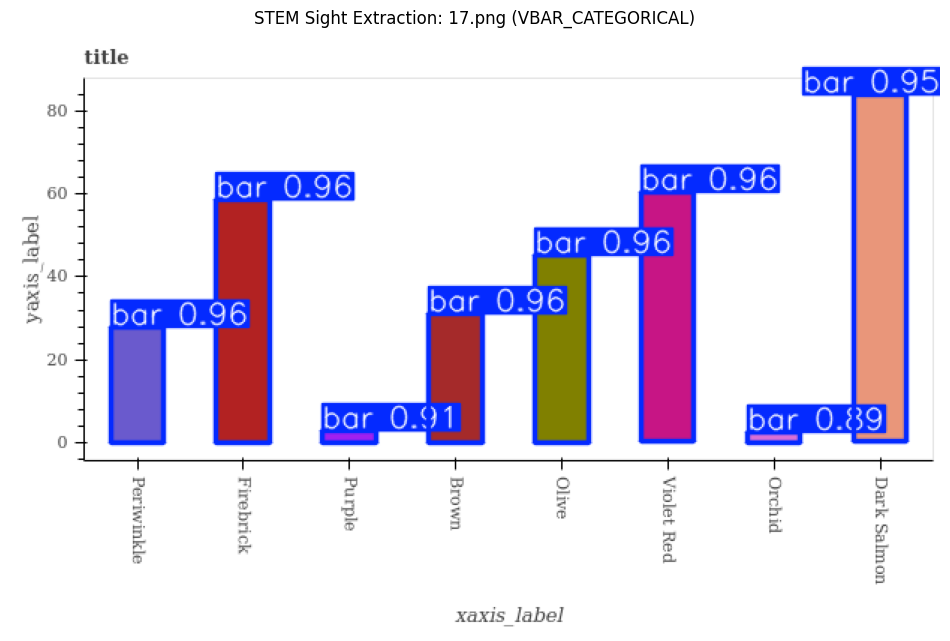

In [1]:
import torch
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image
from ultralytics import YOLO
import easyocr
import warnings
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import re
import torch.nn.functional as F

# Suppress annoying Mac/MPS warnings to keep the terminal clean
warnings.filterwarnings("ignore")

# ==========================================
# 1. LOAD ALL AI MODELS
# ==========================================
print("🧠 Booting up STEM Sight AI Models...")

# A. Chart Classifier
classifier = models.resnet18() 
classifier.fc = torch.nn.Linear(classifier.fc.in_features, 5)  
classifier.load_state_dict(torch.load('graph_classifier_real.pth', map_location='cpu'))
classifier.eval()

# 🚨 FIXED CLASS NAMES: Now matching PyTorch's default alphabetical sorting 🚨
CLASS_NAMES = ['dot_line', 'hbar_categorical', 'line', 'pie', 'vbar_categorical'] 

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# B. YOLO Bar Detector
yolo_model = YOLO("./Bar_Model_Final/weights/best.pt") # Update path if needed

# C. OCR Text Reader
ocr_reader = easyocr.Reader(['en'], gpu=True)

# Helper function to safely extract numbers (handles floats, negatives, and ignores text)
def extract_number(text_str):
    matches = re.findall(r'-?\d+\.?\d*', text_str.replace(',', ''))
    if matches:
        return float(matches[0])
    
    text_clean = text_str.strip().upper()
    if text_clean == 'O': return 0.0
    if text_clean == 'S': return 5.0
    if text_clean in ['I', 'L']: return 1.0
    return None

# ==========================================
# 2. THE EXTRACTION ENGINE
# ==========================================
def extract_full_chart_data(image_path):
    print(f"\n🚀 Analyzing: {image_path}")
    print("-" * 40)
    
    # --- STEP 1: Classify Chart Type ---
    img_pil = Image.open(image_path).convert('RGB')
    img_tensor = transform(img_pil).unsqueeze(0)
    with torch.no_grad():
        outputs = classifier(img_tensor)
        probabilities = F.softmax(outputs, dim=1)[0]
        _, predicted = torch.max(outputs, 1)
        chart_type = CLASS_NAMES[predicted.item()]
        
    print(f"📊 Top Prediction: {chart_type.upper()}")
    print("  Confidence Scores:")
    for i, prob in enumerate(probabilities):
        print(f"    - {CLASS_NAMES[i]}: {prob.item() * 100:.2f}%")

    # --- STEP 2: Detect Bars (YOLO) ---
    results = yolo_model(image_path, conf=0.8, iou=0.4, imgsz=1024, verbose=False)
    boxes = results[0].boxes.xyxy.cpu().numpy()
    
    if len(boxes) == 0:
        print("❌ No bars detected.")
        return
        
    # --- STEP 3: Read Text & Numbers (OCR) with Upscaling ---
    img_cv = cv2.imread(image_path)
    img_upscaled = cv2.resize(img_cv, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    
    ocr_results = ocr_reader.readtext(img_upscaled)
    numbers = []
    text_labels = []
    
    for (bbox, text, prob) in ocr_results:
        cx = ((bbox[0][0] + bbox[1][0]) / 2) / 2.0
        cy = ((bbox[0][1] + bbox[2][1]) / 2) / 2.0
        
        val = extract_number(text)
        if val is not None:
            numbers.append({'val': val, 'x': cx, 'y': cy})
        else:
            text_labels.append({'text': text, 'x': cx, 'y': cy})

    # --- STEP 4: Process based on Chart Type ---
    final_data = []
    
    if 'hbar' in chart_type.lower():
        lowest_bar_bottom = boxes[:, 3].max()
        axis_nums = sorted([n for n in numbers if n['y'] > lowest_bar_bottom - 20], key=lambda d: d['x'])
        
        if len(axis_nums) >= 2:
            units_per_pixel = (axis_nums[-1]['val'] - axis_nums[0]['val']) / (axis_nums[-1]['x'] - axis_nums[0]['x'])
            zero_x_pixel = axis_nums[0]['x'] - (axis_nums[0]['val'] / units_per_pixel)
        else:
            units_per_pixel = 1.0
            zero_x_pixel = boxes[:, 0].min() 

        sorted_boxes = sorted(boxes, key=lambda b: b[1]) 
        
        for box in sorted_boxes:
            x1, y1, x2, y2 = box
            bar_cy = (y1 + y2) / 2
            if (x2 - x1) < 10 or (y2 - y1) < 5: continue 
            
            possible_labels = [l for l in text_labels if l['x'] < x1]
            if possible_labels:
                best_label = min(possible_labels, key=lambda l: abs(l['y'] - bar_cy))
                label_text = best_label['text']
            else:
                label_text = "Unknown Category"
                
            real_val = (x2 - zero_x_pixel) * units_per_pixel
            final_data.append((label_text, round(real_val, 2)))

    elif 'vbar' in chart_type.lower():
        leftmost_bar_edge = boxes[:, 0].min()
        axis_nums = sorted([n for n in numbers if n['x'] < leftmost_bar_edge + 20], key=lambda d: d['y'], reverse=True)
        
        if len(axis_nums) >= 2:
            units_per_pixel = abs((axis_nums[-1]['val'] - axis_nums[0]['val']) / (axis_nums[-1]['y'] - axis_nums[0]['y']))
            zero_y_pixel = axis_nums[0]['y'] + (axis_nums[0]['val'] / units_per_pixel)
        else:
            units_per_pixel = 1.0
            zero_y_pixel = boxes[:, 3].max() 

        sorted_boxes = sorted(boxes, key=lambda b: b[0]) 
        
        for box in sorted_boxes:
            x1, y1, x2, y2 = box
            bar_cx = (x1 + x2) / 2
            if (x2 - x1) < 5 or (y2 - y1) < 10: continue 
            
            possible_labels = [l for l in text_labels if l['y'] > y2]
            if possible_labels:
                best_label = min(possible_labels, key=lambda l: abs(l['x'] - bar_cx))
                label_text = best_label['text']
            else:
                label_text = "Unknown Category"
                
            real_val = (zero_y_pixel - y1) * units_per_pixel
            final_data.append((label_text, round(real_val, 2)))

    else:
        print("⚠️ Not a bar chart.")
        return

    # --- FINAL OUTPUT TEXT ---
    print("\n📈 FINAL EXTRACTED DATA:")
    for label, value in final_data:
        print(f"  {label}: {value}")
        
    # --- DISPLAY THE GRAPH WITH YOLO BOXES ---
    annotated_img = results[0].plot() 
    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_img_rgb)
    file_name = os.path.basename(image_path)
    plt.title(f"STEM Sight Extraction: {file_name} ({chart_type.upper()})")
    plt.axis('off')
    plt.show()

    return final_data

# ==========================================
# 3. RUN THE ENGINE
# ==========================================
if __name__ == "__main__":
    my_image = "./../FigureQA_Dataset/no_annot_test1/png/17.png" 
    extracted_results = extract_full_chart_data(my_image)